**Table of contents**<a id='toc0_'></a>

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import time

import numpy as np
import numba as nb
import matplotlib.pyplot as plt

from consav.grids import equilogspace
from consav.markov import log_rouwenhorst
from consav.linear_interp import interp_1d
from consav.golden_section_search import optimizer

# Solving the buffer-stock model with VFI

The previous notebook solved a deterministic problem with a known answer.
We now add the two ingredients that the permanent income hypothesis is missing: *income risk* and a *borrowing constraint*.
There is no closed form any more.

The horizon is again infinite, so as in the second part of the previous notebook we iterate the backward step until the value function stops moving.

## The model

$$
\begin{aligned}
v(z_t,a_{t-1}) &= \max_{c_t} \frac{c_t^{1-\sigma}}{1-\sigma} + \beta \mathbb{E}_t\left[v(z_{t+1},a_t)\right] \\
&\text{s.t.} \\
m_t &= (1+r)a_{t-1} + wz_t \\
a_t &= m_t - c_t \geq \underline{a} \\
\log z_{t+1} &= \rho_z \log z_t + \psi_{t+1}, \qquad \psi_{t+1}\sim\mathcal{N}(0,\sigma_\psi^2), \qquad \mathbb{E}[z_t]=1
\end{aligned}
$$

Note that $v$ carries no time subscript: the problem is stationary, so the policy function is the same in every period.

The income process is a continuous AR(1), which we cannot put on a computer as it stands.
We discretize it into a $\#_z$-state Markov chain with `log_rouwenhorst`, which returns the grid, the transition matrix and the ergodic distribution.
Rouwenhorst is the method of choice at high persistence; `tauchen` is the alternative.

In [2]:
class Parameters:
    def __init__(self):
        # preferences
        self.beta = 0.96
        self.sigma = 2.0

        # prices
        self.r = 0.02
        self.w = 1.0

        # income risk
        self.rho_z = 0.95
        self.sigma_psi = 0.10
        self.Nz = 7
        self.z_grid,self.z_trans,self.z_ergodic,_,_ = log_rouwenhorst(self.rho_z,self.sigma_psi,self.Nz)

        # grids
        self.Na = 300
        self.a_min = 0.0
        self.a_max = 100.0
        self.a_grid = equilogspace(self.a_min,self.a_max,self.Na)

par = Parameters()

In [3]:
print('z_grid    =',np.round(par.z_grid,4))
print('z_ergodic =',np.round(par.z_ergodic,4))
print('mean of z =',np.sum(par.z_grid*par.z_ergodic))

z_grid    = [0.4336 0.5632 0.7315 0.9501 1.2341 1.6029 2.082 ]
z_ergodic = [0.0156 0.0938 0.2344 0.3125 0.2344 0.0937 0.0156]
mean of z = 0.9999999999999998


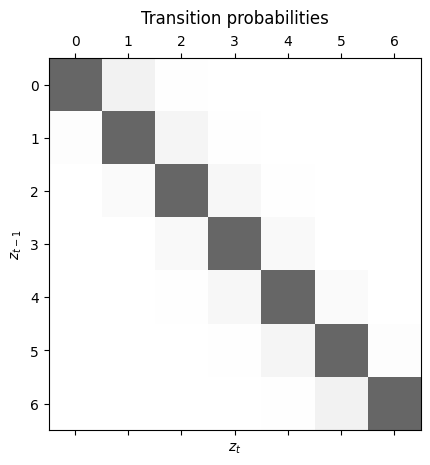

In [4]:
plt.matshow(par.z_trans,cmap='Greys',alpha=0.6)
plt.xlabel('$z_t$')
plt.ylabel('$z_{t-1}$')
plt.title('Transition probabilities',pad=25)
plt.savefig('figs/bs_z_trans.pdf')
plt.show()

## Value function iteration

Algorithm:
Guess a value function $v(z_t,a_{t-1})$. Then
1. Take the expectation, $\underline{v}(z_t,a_t) = \mathbb{E}_t[v(z_{t+1},a_t)]$, one matrix product with $\Pi_z$
2. For each $(z_t,a_{t-1})$ on the grids, compute cash-on-hand $m_t = (1+r)a_{t-1}+wz_t$
3. Maximize $u(c_t)+\beta\underline{v}(z_t,m_t-c_t)$ over $c_t \in [0,m_t-\underline{a}]$, using $\underline{v}$ interpolated off the grid
4. Store $c^{\ast}(z_t,a_{t-1})$, $a^{\ast}(z_t,a_{t-1}) = m_t-c^{\ast}$ and the value attained

Iterate until convergence.

A few remarks on the implementation.

The expectation is taken *before* the maximization.
Doing it the other way round would cost $\#_z$ interpolations per guess of $c_t$ instead of one.
We call $\underline{v}$ the *beginning-of-period* value function (of period $t+1$, before $z_{t+1}$ is drawn), which is also the convention `GEModelTools` uses from lecture 04 on.

`value_of_choice` is *exactly* the one from the previous notebook: risk changes what we feed it, the expected value $\underline{v}$, not the function itself.

The loop over income states runs in parallel with `nb.prange`, since the states do not talk to each other within a step.

Any terminal guess converges (contraction), but a guess closer to the fixed point converges faster.
Instead of starting from the last period of life as in the previous notebook, we guess that households consume the annuity value $ra_{t-1}+wz_t$ forever.

In [5]:
@nb.njit
def value_of_choice(c,m,beta,sigma,a_grid,v_plus):
    """ negative of the value of consuming c out of cash-on-hand m """

    # a. end-of-period assets implied by the choice
    a = m - c # using budget constraint

    # b. utility today plus discounted continuation value
    utility = c**(1-sigma)/(1-sigma)
    continuation = interp_1d(a_grid,v_plus,a)

    return -(utility + beta*continuation)

In [ ]:
@nb.njit(parallel=True)
def vfi_step(beta,sigma,r,w,a_min,z_grid,z_trans,a_grid,v_plus,v,c,a):
    """ one backward step of value function iteration """

    Nz,Na = v_plus.shape

    # a. expectation step
    vbeg_plus = z_trans@v_plus

    # b. solve step
    # loop over both states
    for i_z in nb.prange(Nz): # idiosyncratic productivity
        for i_a_lag in range(Na): # asset

            # i. cash-on-hand and maximum consumption
            m = (1+r)*a_grid[i_a_lag] + w*z_grid[i_z]
            c_max = m - a_min # a_min = borrrowing constraint

            # ii. optimize
            c[i_z,i_a_lag] = optimizer(value_of_choice,1e-8,c_max,
                args=(m,beta,sigma,a_grid,vbeg_plus[i_z]),tol=1e-10)

            # iii. save
            a[i_z,i_a_lag] = m - c[i_z,i_a_lag] # use budget constraint to get a'
            v[i_z,i_a_lag] = -value_of_choice(c[i_z,i_a_lag],m,beta,sigma,a_grid,vbeg_plus[i_z]) # save new guess of value function

In [7]:
def solve_vfi_ss(par,max_iter=10_000,tol=1e-8):
    """ solve the infinite-horizon problem with value function iteration """

    c = np.zeros((par.Nz,par.Na))
    a = np.zeros((par.Nz,par.Na))
    v = np.zeros((par.Nz,par.Na))

    # a. initial guess: consume the annuity value forever
    c_guess = par.r*par.a_grid[np.newaxis,:] + par.w*par.z_grid[:,np.newaxis]
    v_plus = c_guess**(1-par.sigma)/(1-par.sigma)/(1-par.beta)

    errors = []

    # b. iterate
    for it in range(max_iter):

        vfi_step(par.beta,par.sigma,par.r,par.w,par.a_min,
            par.z_grid,par.z_trans,par.a_grid,v_plus,v,c,a)

        error = np.max(np.abs(v-v_plus))
        errors.append(error)
        if error < tol: break

        v_plus[:] = v

    return c,a,v,errors

In [8]:
t0 = time.time()
c,a,v,errors = solve_vfi_ss(par)

print(f'converged in {len(errors)} iterations and {time.time()-t0:.2f} seconds')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


converged in 339 iterations and 1.01 seconds


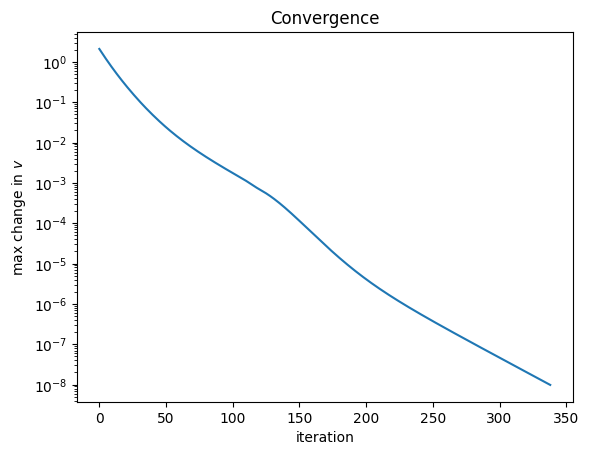

In [9]:
plt.plot(errors)
plt.yscale('log')
plt.title('Convergence')
plt.xlabel('iteration')
plt.ylabel('max change in $v$')
plt.savefig('figs/bs_vfi_convergence.pdf')
plt.show()

The error falls at a constant rate on a log scale: each backward step shrinks the distance to the fixed point by a factor $\beta$, which is what the contraction mapping theorem promises.
With $\beta = 0.96$ it takes about 340 iterations.
The permanent income model of the previous notebook, with $\beta \approx 0.98$, needed about 1,500: *the closer $\beta$ is to one, the slower value function iteration converges*.

## Results

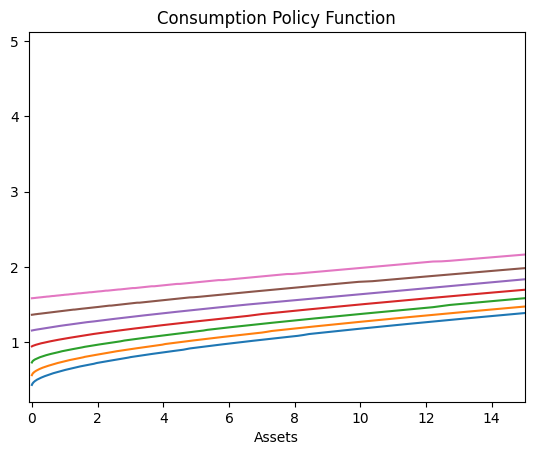

In [10]:
plt.plot(par.a_grid,c.T)
plt.xlim(-0.1,15)
plt.title('Consumption Policy Function')
plt.xlabel('Assets')
plt.savefig('figs/bs_c_func.pdf')
plt.show()

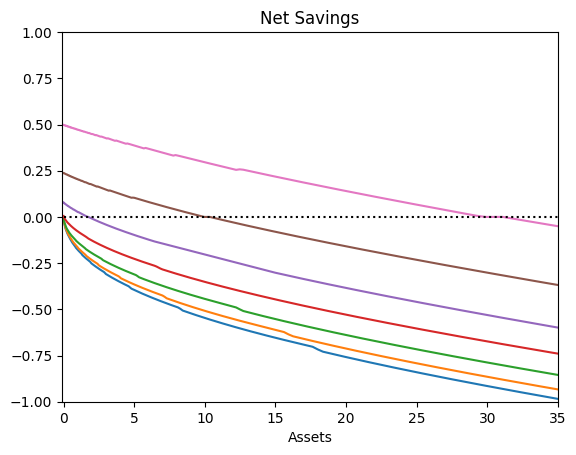

In [15]:
plt.plot(par.a_grid,(a-par.a_grid[np.newaxis,:]).T)
plt.plot(par.a_grid,np.zeros_like(par.a_grid),linestyle=':',color='black')
plt.xlim(-0.1,35)
plt.ylim(-1,1)
plt.title('Net Savings')
plt.xlabel('Assets')
plt.savefig('figs/bs_a_func.pdf')
plt.show()

### MPC

The marginal propensity to consume out of a windfall is the slope of the consumption function in cash-on-hand.
Since $m_t = (1+r)a_{t-1}+wz_t$, we get it from a first difference along the asset grid,

$$
\text{MPC}(z_t,a_{t-1}) \approx \frac{c^{\ast}(z_t,a_{t-1}')-c^{\ast}(z_t,a_{t-1})}{(1+r)(a_{t-1}'-a_{t-1})}
$$

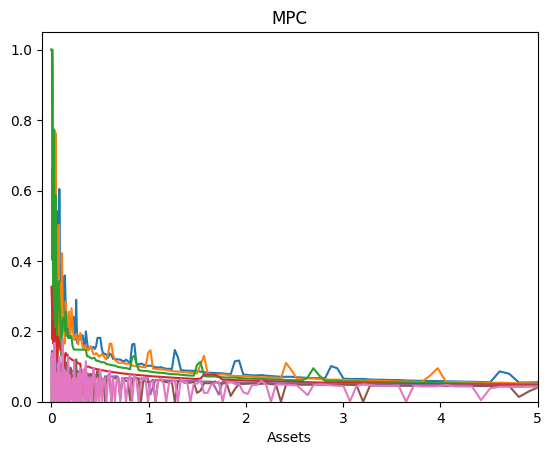

MPC at the constraint:  1.0000
PIH benchmark, r/(1+r): 0.0196
negative MPCs:          30


In [12]:
MPC = np.zeros((par.Nz,par.Na))
MPC[:,:-1] = (c[:,1:]-c[:,:-1])/((1+par.r)*(par.a_grid[1:]-par.a_grid[:-1]))
MPC[:,-1] = MPC[:,-2]

plt.plot(par.a_grid,MPC.T)
plt.xlim(-0.1,5)
plt.ylim(0,1.05)
plt.title('MPC')
plt.xlabel('Assets')
plt.savefig('figs/bs_MPC.pdf')
plt.show()

print(f'MPC at the constraint:  {MPC[0,0]:.4f}')
print(f'PIH benchmark, r/(1+r): {par.r/(1+par.r):.4f}')
print(f'negative MPCs:          {np.sum(MPC < 0)}')

The MPC is one at the constraint and falls with wealth, as the slides say.
But the curve is ragged, and 30 of the first differences are negative, which makes no economic sense.
This is a numerical artefact of VFI: the interpolated value function is piecewise linear, so the optimizer sometimes parks $a_t$ exactly on a grid point, and the first difference of $c^{\ast}$ jumps.
The next notebook fixes this.

## Simulating a household

The policy function tells us what a household *would* do in any state.
A *Monte Carlo simulation* shows what one household actually does: draw a random income path from the Markov chain and run the budget constraint forward, reading consumption off the policy function each period.
This is the same forward loop as in the previous notebook, plus one random draw per period.

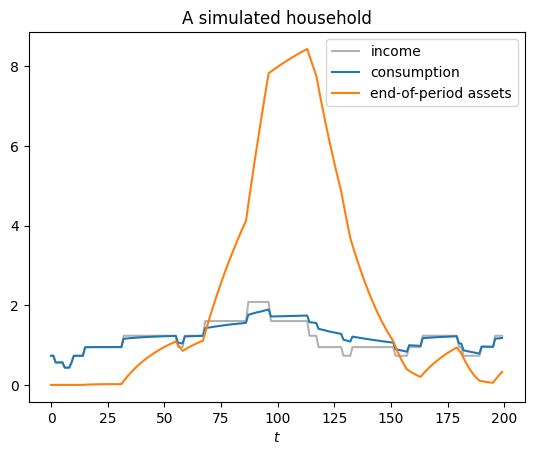

In [13]:
np.random.seed(1917)
T_sim = 200

i_z_sim = np.zeros(T_sim,dtype=np.int64)
c_sim = np.zeros(T_sim)
a_sim = np.zeros(T_sim)

# a. initial state: no wealth, productivity drawn from the ergodic distribution
a_lag = 0.0
i_z = np.random.choice(par.Nz,p=par.z_ergodic)

# b. run the budget constraint forward
for t in range(T_sim):

    i_z_sim[t] = i_z
    c_sim[t] = interp_1d(par.a_grid,c[i_z],a_lag)
    a_sim[t] = (1+par.r)*a_lag + par.w*par.z_grid[i_z] - c_sim[t]

    a_lag = a_sim[t]
    i_z = np.random.choice(par.Nz,p=par.z_trans[i_z])

plt.plot(par.w*par.z_grid[i_z_sim],label='income',color='black',alpha=0.3)
plt.plot(c_sim,label='consumption')
plt.plot(a_sim,label='end-of-period assets')
plt.title('A simulated household')
plt.xlabel('$t$')
plt.legend()
plt.savefig('figs/bs_simulation.pdf')
plt.show()

Consumption is visibly smoother than income, but far from flat: the household builds a buffer in good times and runs it down in bad ones.
When a bad spell lasts long enough the buffer runs out, the constraint binds, and consumption is forced to follow income one for one.
Notebook 05 instead tracks the entire *distribution* of households at once, with no random draws and no simulation noise.